In [26]:
from pathlib import Path
import sys

repo_root = next((parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (parent / 'ndnf_pipeline').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate the repository root')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [27]:
import datajoint as dj
dj.config.load('/Users/moldor/Documents/KOKI/secrets/dj_local_conf_NDNF_behavior_KOKI.json')#dj_local_conf_NDNF_behavior_KOKI.json #dj_local_conf_NDNF_behavior_HUN cs16-datajoint.koki.local
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
import numpy as np
# connect to the database

[2026-07-16 09:16:28,029][INFO]: DataJoint is configured from /Users/moldor/Documents/KOKI/secrets/dj_local_conf_NDNF_behavior_KOKI.json


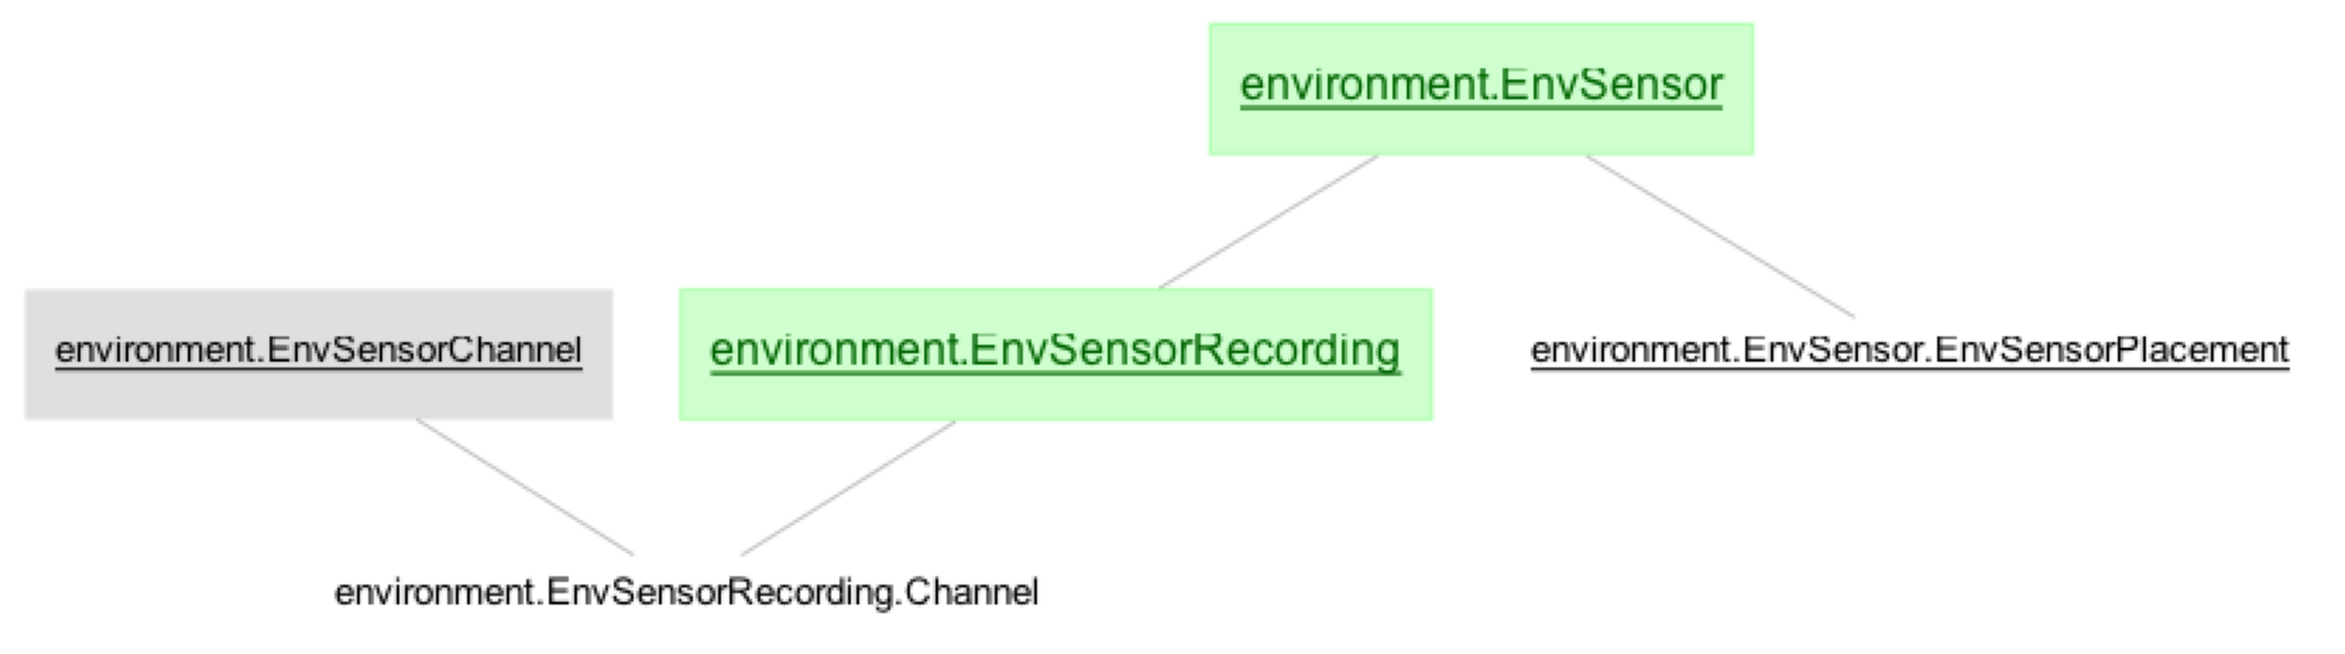

In [28]:
# take a look at the environment schema
from ndnf_pipeline import environment

d = dj.Diagram(environment)
fig = plt.figure(figsize = (30, 30))
d.draw()

In [29]:
environment.EnvSensor.EnvSensorPlacement()

sensor_id e.g. NDNF-#1,placement_date,institute_id,building,room,rig,"location_description ""Marton's desk"", ""top of ventilated box""",placement_comment
NDNF-#1,2026-03-01,KOKI,Tower,213,None,Marton's desk,testing
NDNF-#1,2026-03-18,KOKI,Tower,711,None,Top of ventilated box,testing
NDNF-#1,2026-05-31,KOKI,Tower,704,None,"On the parapet, window side",testing
NDNF-#2,2026-03-01,KOKI,Tower,212,None,on the shelf,testing
NDNF-#2,2026-03-22,KOKI,Tower,711,None,Top of ventilated box,"sensor has problems, not recording, not connecting to the server"
NDNF-#2,2026-03-27,KOKI,Tower,704,None,"On the parapet, window side","testing, sensor put on 5V power source, now it's communicating with the server"
NDNF-#2,2026-05-31,KOKI,Tower,711,None,"Behavior room, next to whiteboard","Final location, testing temperature control and humidity"


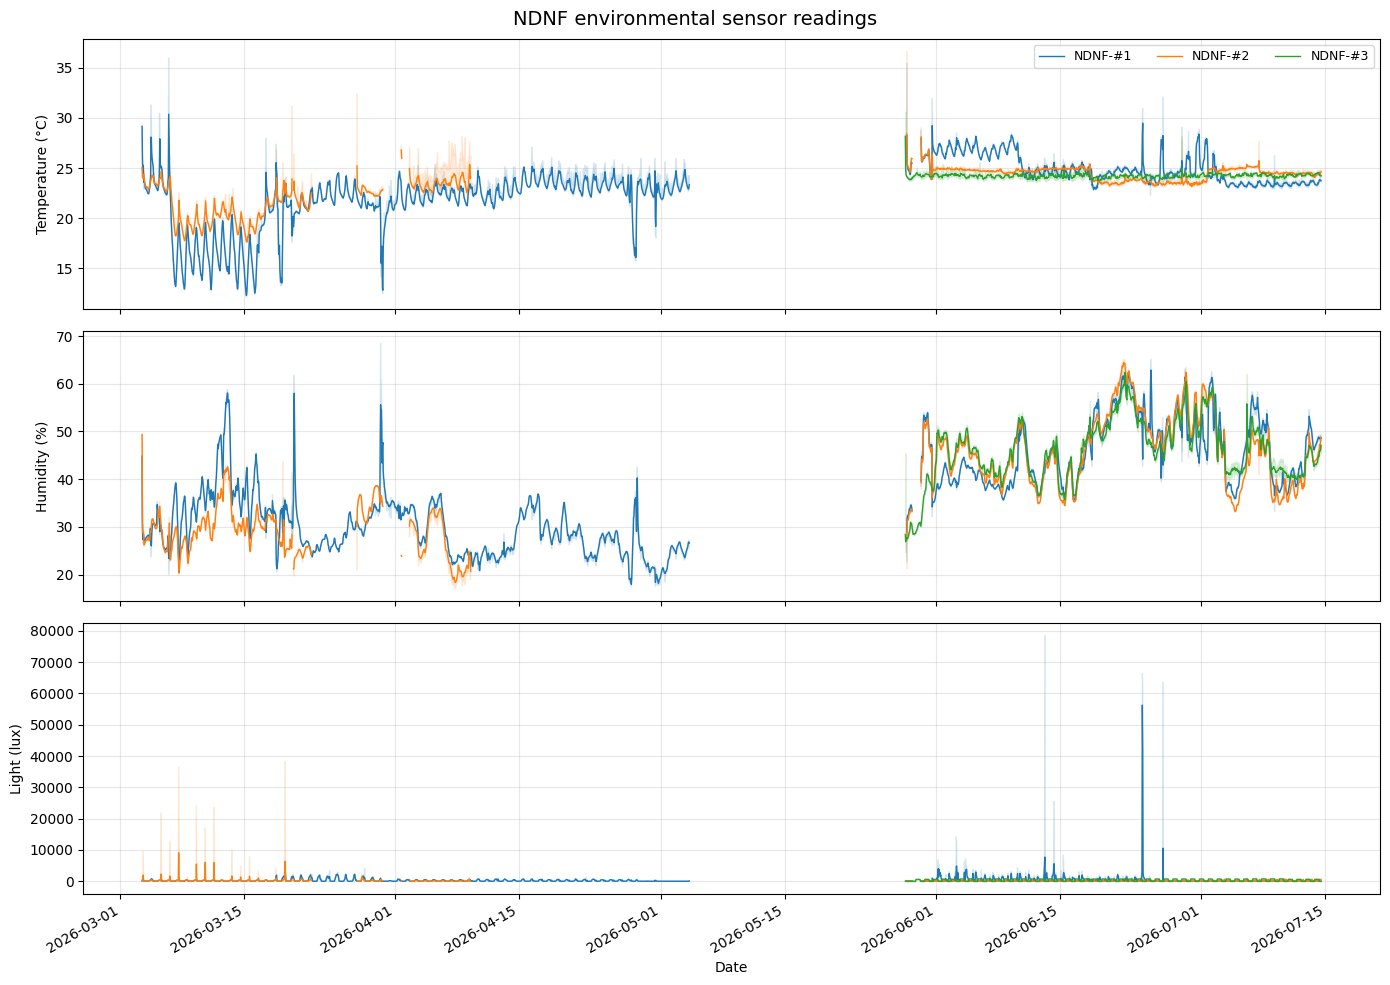

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from ndnf_pipeline import environment

channels_of_interest = ['Temperature', 'Humidity', 'Light']
units = {'Temperature': '°C', 'Humidity': '%', 'Light': 'lux'}

df = (environment.EnvSensorRecording.Channel
      & f"channel_name in {tuple(channels_of_interest)}").fetch(format='frame').reset_index()
df['recording_datetime'] = pd.to_datetime(df['recording_datetime'])
df = df.sort_values('recording_datetime')

sensors = sorted(df['sensor_id'].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(channels_of_interest), 1, figsize=(14, 10), sharex=True)

for ax, channel in zip(axes, channels_of_interest):
    sub = df[df['channel_name'] == channel]
    for i, sensor_id in enumerate(sensors[:]):
        s = sub[sub['sensor_id'] == sensor_id].set_index('recording_datetime').sort_index()
        if s.empty:
            continue
        full_range = pd.date_range(s.index.min(), s.index.max(), freq='h')
        s = s.reindex(full_range)  # missing hours become NaN -> gaps in the line
        color = colors[i % len(colors)]
        ax.plot(s.index, s['value_avg'], label=sensor_id, color=color, linewidth=1)
        ax.fill_between(s.index, s['value_min'], s['value_max'], color=color, alpha=0.15)
    ax.set_ylabel(f"{channel} ({units[channel]})")
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper right', ncol=len(sensors), fontsize=9)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle('NDNF environmental sensor readings', fontsize=14)
plt.tight_layout()
plt.show()

# sensor 1 has data between 03.28-05.04   --  but no mouse weight data yet
# all 3 sensors have data from 05.28
# 711 is the animal room

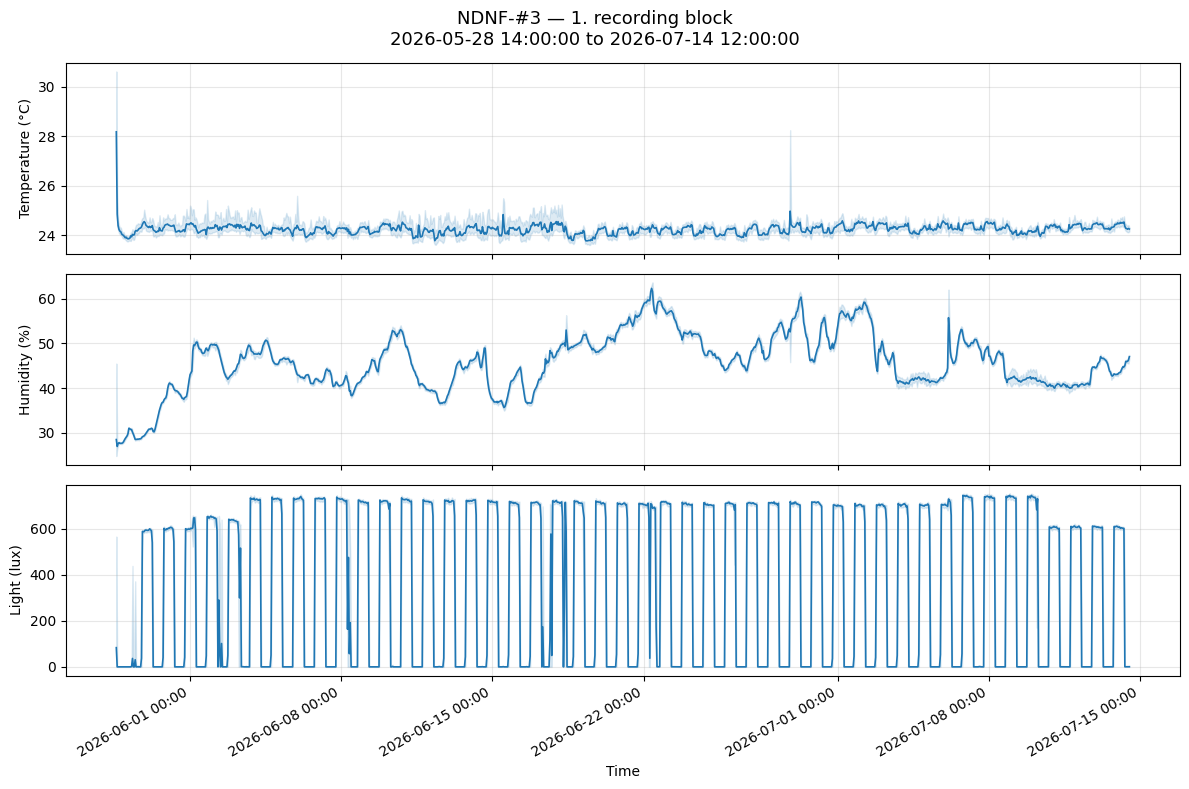

In [31]:
# At this point the sensor is chosen manually. Replacing sensors is not yet handled.

sensor_id = 'NDNF-#3'
group_id = 0
channels_of_interest = ['Temperature', 'Humidity', 'Light']
units = {'Temperature': '°C', 'Humidity': '%', 'Light': 'lux'}

# find the first consecutive recording block for this sensor
times = (environment.EnvSensorRecording & {'sensor_id': sensor_id}).fetch('recording_datetime')
times = pd.to_datetime(pd.Series(times)).sort_values().reset_index(drop=True)
gap_threshold = pd.Timedelta(hours=1.5)
group_ids = (times.diff() > gap_threshold).cumsum()
first_run = times[group_ids == group_id]
start, end = first_run.min(), first_run.max()

# fetch the 3 channels for this sensor, restricted to that period
df = ((environment.EnvSensorRecording.Channel & {'sensor_id': sensor_id})
      & f"channel_name in {tuple(channels_of_interest)}"
      & f"recording_datetime between '{start}' and '{end}'"
      ).fetch(format='frame').reset_index()
df['recording_datetime'] = pd.to_datetime(df['recording_datetime'])
df = df.sort_values('recording_datetime')

fig, axes = plt.subplots(len(channels_of_interest), 1, figsize=(12, 8), sharex=True)

for ax, channel in zip(axes, channels_of_interest):
    sub = df[df['channel_name'] == channel]
    ax.plot(sub['recording_datetime'], sub['value_avg'], color='tab:blue', linewidth=1.2)
    ax.fill_between(sub['recording_datetime'], sub['value_min'], sub['value_max'], color='tab:blue', alpha=0.15)
    ax.set_ylabel(f"{channel} ({units[channel]})")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'{sensor_id} — {group_id+1}. recording block\n{start} to {end}', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# Weight measurements during the chosen period

wr_log = (lab.WaterRestriction.WaterRestrictionLog
          & f"log_datetime between '{start}' and '{end}'").fetch(format='frame').reset_index()
wr_log = wr_log.sort_values(['subject_id', 'log_datetime'])
print(wr_log.shape[0])
wr_log.head(10)

279


,subject_id,water_restriction_id,log_datetime,user_name,weight,weight_after_watering,water_given,water_earned,notes
0,M013,M013,2026-06-11 16:30:00,ridas,29.50,None,0.000,None,First day of water restriction- scruffy coat
1,M013,M013,2026-06-12 15:40:59,rozmar,25.50,None,0.800,None,mouse drinking well
2,M013,M013,2026-06-13 13:55:10,rozmar,24.30,None,0.500,None,
3,M013,M013,2026-06-14 15:16:29,ridas,23.30,None,3.000,None,giving back water for 5 minutes
4,M013,M013,2026-06-15 14:12:44,ridas,23.50,None,2.000,None,weight after water = 25
5,M013,M013,2026-06-16 16:20:46,ridas,23.50,None,1.000,None,weight after water-24.4
6,M013,M013,2026-06-17 18:21:03,ridas,23.50,None,1.000,None,weight after water- 24.2
7,M013,M013,2026-06-18 17:06:05,ridas,22.90,None,1.000,None,weight after water- 24
8,M013,M013,2026-06-19 18:37:50,rozmar,22.80,None,2.000,None,
9,M013,M013,2026-06-20 16:03:44,ridas,22.60,23.90,1.300,None,digging a lot; weight after water- 23.9


Using NDNF-#3, window 2026-05-28 14:00:00 to 2026-07-14 12:00:00


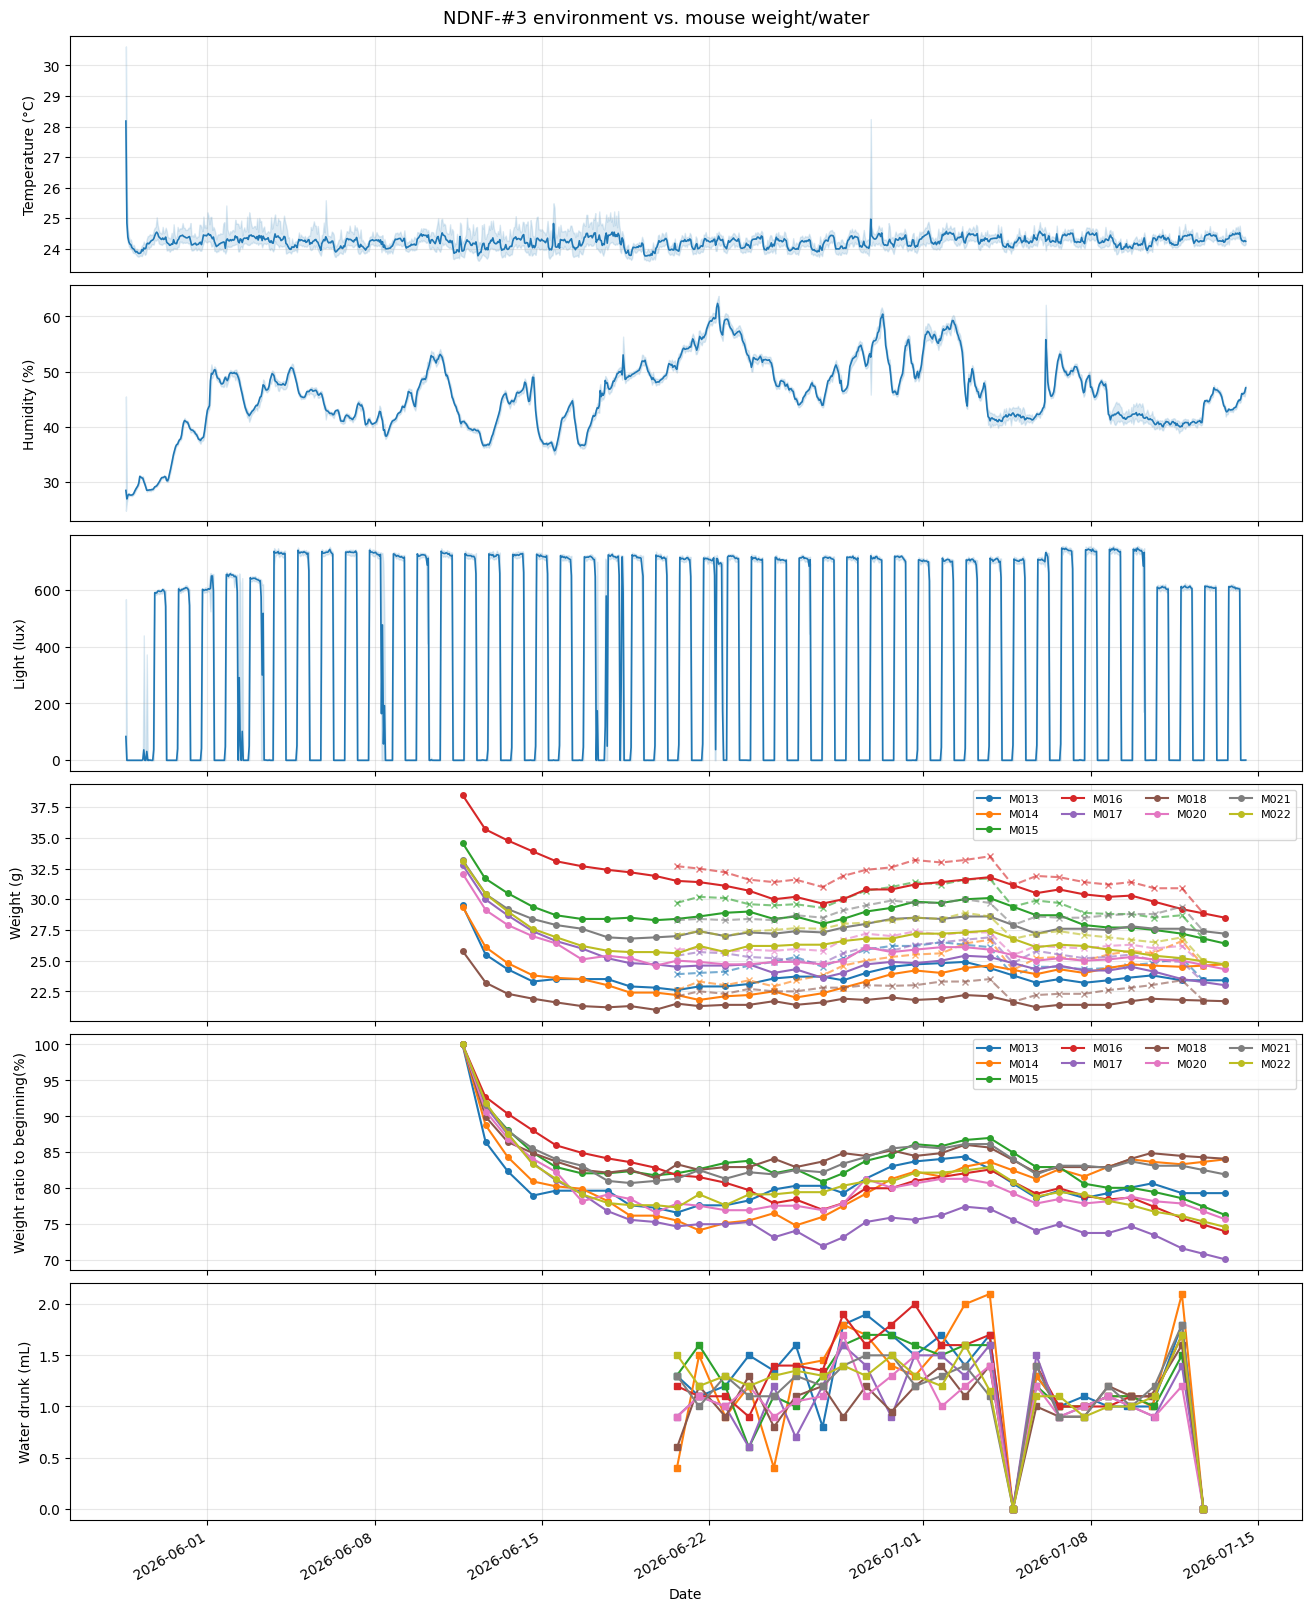

In [33]:
sensor_id = 'NDNF-#3'
group_id = 0

# ---- 1. this sensor's chosen recording block ----
times = (environment.EnvSensorRecording & {'sensor_id': sensor_id}).fetch('recording_datetime')
times = pd.to_datetime(pd.Series(times)).sort_values().reset_index(drop=True)
gap_threshold = pd.Timedelta(hours=1.5)
group_ids = (times.diff() > gap_threshold).cumsum()
first_run = times[group_ids == group_id]
env_start, env_end = first_run.min(), first_run.max()
print(f"Using {sensor_id}, window {env_start} to {env_end}")

# ---- 2. environment channels for that sensor + period ----
channels_of_interest = ['Temperature', 'Humidity', 'Light']
units = {'Temperature': '°C', 'Humidity': '%', 'Light': 'lux'}

env_df = ((environment.EnvSensorRecording.Channel & {'sensor_id': sensor_id})
          & f"channel_name in {tuple(channels_of_interest)}"
          & f"recording_datetime between '{env_start}' and '{env_end}'"
          ).fetch(format='frame').reset_index()
env_df['recording_datetime'] = pd.to_datetime(env_df['recording_datetime'])
env_df = env_df.sort_values('recording_datetime')

# ---- 3. water restriction logs in the same period ----
wr_log = (lab.WaterRestriction.WaterRestrictionLog
          & f"log_datetime between '{env_start}' and '{env_end}'").fetch(format='frame').reset_index()
for col in ['weight', 'weight_after_watering', 'water_given']:
    wr_log[col] = pd.to_numeric(wr_log[col], errors='coerce')
wr_log['log_datetime'] = pd.to_datetime(wr_log['log_datetime'])
wr_log = wr_log.sort_values(['subject_id', 'log_datetime'])

# ---- 3b. insert synthetic "no recording" logs for each skipped day ----
one_day = pd.Timedelta(days=1)

synthetic_rows = []
for subject_id, grp in wr_log.groupby('subject_id'):
    grp = grp.sort_values('log_datetime').reset_index(drop=True)
    for i in range(len(grp) - 1):
        t0, t1 = grp.loc[i], grp.loc[i + 1]
        gap = t1['log_datetime'] - t0['log_datetime']
        n_missing = round(gap / one_day) - 1  # e.g. gap ~2 days -> 1 missing log, ~3 days -> 2 missing logs
        if n_missing < 1:
            continue
        for k in range(1, n_missing + 1):
            frac = k / (n_missing + 1)
            interp_weight = t0['weight'] + (t1['weight'] - t0['weight']) * frac
            synthetic_rows.append({
                'subject_id': subject_id,
                'water_restriction_id': t0['water_restriction_id'],
                'log_datetime': t0['log_datetime'] + gap * frac,
                'user_name': 'synthetic',
                'weight': interp_weight,
                'weight_after_watering': interp_weight,
                'water_given': 0.0,
                'water_earned': None,
                'notes': f'inferred: no log recorded this day ({k}/{n_missing})',
            })

if synthetic_rows:
    wr_log = pd.concat([wr_log, pd.DataFrame(synthetic_rows)], ignore_index=True)
    wr_log = wr_log.sort_values(['subject_id', 'log_datetime']).reset_index(drop=True)

mice = sorted(wr_log['subject_id'].unique())
colors = plt.cm.tab10.colors

# ---- 4. plot ----
fig, axes = plt.subplots(6, 1, figsize=(13, 16), sharex=True, constrained_layout=True)

for ax, channel in zip(axes[:3], channels_of_interest):
    sub = env_df[env_df['channel_name'] == channel]
    ax.plot(sub['recording_datetime'], sub['value_avg'], color='tab:blue', linewidth=1.2)
    ax.fill_between(sub['recording_datetime'], sub['value_min'], sub['value_max'], color='tab:blue', alpha=0.15)
    ax.set_ylabel(f"{channel} ({units[channel]})")
    ax.grid(alpha=0.3)

ax_weight = axes[3]
for i, subject_id in enumerate(mice):
    s = wr_log[wr_log['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax_weight.plot(s['log_datetime'], s['weight'], 'o-', color=color, label=subject_id, markersize=4)
    if s['weight_after_watering'].notna().any():
        ax_weight.plot(s['log_datetime'], s['weight_after_watering'], 'x--', color=color, markersize=4, alpha=0.6)
ax_weight.set_ylabel('Weight (g)')
ax_weight.grid(alpha=0.3)
ax_weight.legend(loc='upper right', ncol=min(len(mice), 4), fontsize=8)

ax_weight = axes[4]
for i, subject_id in enumerate(mice):
    s = wr_log[wr_log['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax_weight.plot(s['log_datetime'], s['weight']/s['weight'].iloc[0]*100, 'o-', color=color, label=subject_id, markersize=4)
ax_weight.set_ylabel('Weight ratio to beginning(%)')
ax_weight.grid(alpha=0.3)
ax_weight.legend(loc='upper right', ncol=min(len(mice), 4), fontsize=8)

ax_water = axes[5]
for i, subject_id in enumerate(mice):
    s = wr_log[wr_log['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax_water.plot(s['log_datetime'], s['weight_after_watering']-s['weight'], 's-', color=color, markersize=4)
ax_water.set_ylabel('Water drunk (mL)')
ax_water.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle(f'{sensor_id} environment vs. mouse weight/water', fontsize=13)
#plt.tight_layout()
plt.show()

In [34]:
wr_log

,subject_id,water_restriction_id,log_datetime,user_name,weight,weight_after_watering,water_given,water_earned,notes
0,M013,M013,2026-06-11 16:30:00,ridas,29.50,NaN,0.0,None,First day of water restriction- scruffy coat
1,M013,M013,2026-06-12 15:40:59,rozmar,25.50,NaN,0.8,None,mouse drinking well
2,M013,M013,2026-06-13 13:55:10,rozmar,24.30,NaN,0.5,None,
3,M013,M013,2026-06-14 15:16:29,ridas,23.30,NaN,3.0,None,giving back water for 5 minutes
4,M013,M013,2026-06-15 14:12:44,ridas,23.50,NaN,2.0,None,weight after water = 25
...,...,...,...,...,...,...,...,...,...
292,M022,M022,2026-07-09 16:55:38,tchaves,25.70,26.70,1.0,None,
293,M022,M022,2026-07-10 16:22:48,rozmar,25.40,26.50,1.0,None,
294,M022,M022,2026-07-11 19:55:05,tchaves,25.20,26.90,2.0,None,
295,M022,M022,2026-07-12 17:33:21,synthetic,24.95,24.95,0.0,None,inferred: no log recorded this day (1/1)


In [35]:
wr_master = lab.WaterRestriction().fetch(format='frame').reset_index()
wr_master['wr_start_weight'] = pd.to_numeric(wr_master['wr_start_weight'], errors='coerce')

wr_log = wr_log.merge(wr_master[['subject_id', 'water_restriction_id', 'wr_start_weight']],
                       on=['subject_id', 'water_restriction_id'], how='left')
wr_log = wr_log.sort_values(['subject_id', 'log_datetime'])

transitions = []
for subject_id, grp in wr_log.groupby('subject_id'):
    grp = grp.sort_values('log_datetime').reset_index(drop=True)
    for i in range(len(grp) - 1):
        t, t1 = grp.loc[i], grp.loc[i + 1]
        if pd.isna(t['weight_after_watering']):
            continue
        elapsed_days = (t1['log_datetime'] - t['log_datetime']).total_seconds() / 86400
        if elapsed_days <= 0:
            continue
        decay = t['weight_after_watering'] - t1['weight']
        transitions.append({
            'subject_id': subject_id,
            't_start': t['log_datetime'],
            't_end': t1['log_datetime'],
            'elapsed_days': elapsed_days,
            'water_given_t': t['weight_after_watering']-t['weight'],
            'decay': decay,
            'wr_start_weight': t['wr_start_weight'],
            'weight_t': t['weight'],
            'weight_ratio_t': t['weight'] / t['wr_start_weight'],
            'net_change': t1['weight'] - t['weight'],
        })

transitions = pd.DataFrame(transitions)
sex_df = lab.Subject().fetch(format='frame')[['sex']].reset_index()[['subject_id', 'sex']]
transitions = transitions.merge(sex_df, on='subject_id', how='left')

print(transitions.shape)

(207, 11)


In [36]:
sensor_id = 'NDNF-#3'

env_all = ((environment.EnvSensorRecording.Channel & {'sensor_id': sensor_id})
           & "channel_name in ('Temperature', 'Humidity')").fetch(format='frame').reset_index()
env_all['recording_datetime'] = pd.to_datetime(env_all['recording_datetime'])

def get_env_means(t_start, t_end):
    mask = (env_all['recording_datetime'] >= t_start) & (env_all['recording_datetime'] < t_end)
    sub = env_all[mask]
    return pd.Series({
        'mean_temp': sub.loc[sub['channel_name'] == 'Temperature', 'value_avg'].mean(),
        'mean_humidity': sub.loc[sub['channel_name'] == 'Humidity', 'value_avg'].mean(),
    })

env_features = transitions.apply(lambda r: get_env_means(r['t_start'], r['t_end']), axis=1)
transitions = pd.concat([transitions, env_features], axis=1).dropna(subset=['mean_temp', 'mean_humidity'])
print("Transition table shape: ", transitions.shape)
transitions.head(10)

Transition table shape:  (207, 13)


,subject_id,t_start,t_end,elapsed_days,water_given_t,decay,wr_start_weight,weight_t,weight_ratio_t,net_change,sex,mean_temp,mean_humidity
0,M013,2026-06-20 16:03:44,2026-06-21 14:21:25,0.928947,1.30,1.00,29.5,22.60,0.766102,0.30,M,24.146168,54.126832
1,M013,2026-06-21 14:21:25,2026-06-22 16:45:35,1.100116,1.10,1.10,29.5,22.90,0.776271,0.00,M,24.230500,58.369735
2,M013,2026-06-22 16:45:35,2026-06-23 16:33:20,0.991493,1.20,1.00,29.5,22.90,0.776271,0.20,M,24.170808,56.684338
3,M013,2026-06-23 16:33:20,2026-06-24 17:33:54,1.042060,1.50,1.05,29.5,23.10,0.783051,0.45,M,24.188056,51.910056
4,M013,2026-06-24 17:33:54,2026-06-25 15:35:14,0.917593,1.35,1.20,29.5,23.55,0.798305,0.15,M,24.154786,47.287800
5,M013,2026-06-25 15:35:14,2026-06-26 18:37:40,1.126690,1.60,1.60,29.5,23.70,0.803390,0.00,M,24.090363,45.652930
6,M013,2026-06-26 18:37:40,2026-06-27 15:17:18,0.860856,0.80,1.10,29.5,23.70,0.803390,-0.30,M,24.195924,48.270343
7,M013,2026-06-27 15:17:18,2026-06-28 14:13:22,0.955602,1.80,1.20,29.5,23.40,0.793220,0.60,M,24.226700,51.417713
8,M013,2026-06-28 14:13:22,2026-06-29 15:51:35,1.068206,1.90,1.40,29.5,24.00,0.813559,0.50,M,24.289496,55.024996
9,M013,2026-06-29 15:51:35,2026-06-30 15:27:17,0.983125,1.70,1.50,29.5,24.50,0.830508,0.20,M,24.236333,50.085567


Not much trend here...

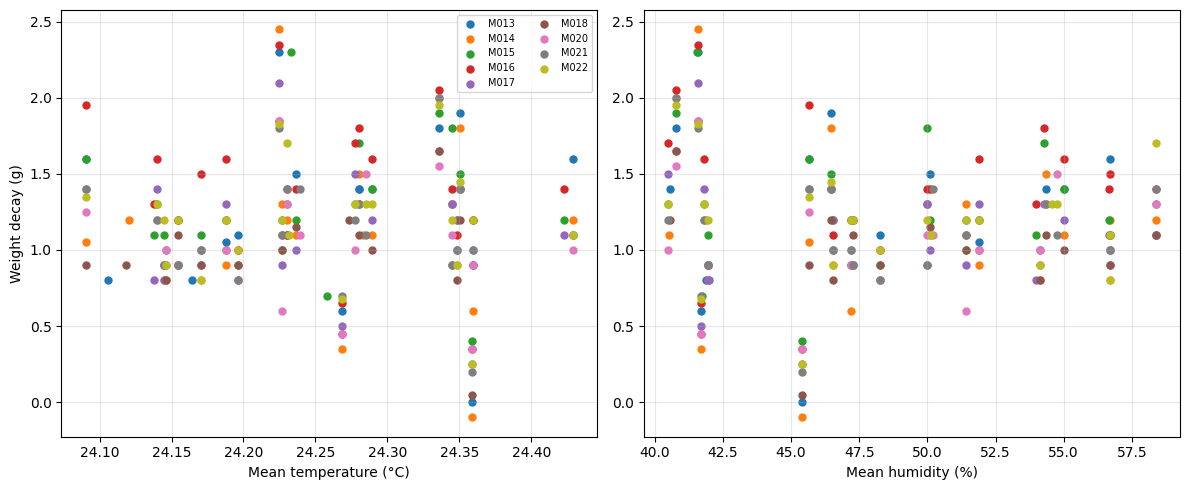

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10.colors
mice = sorted(transitions['subject_id'].unique())

for i, subject_id in enumerate(mice):
    s = transitions[transitions['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    axes[0].scatter(s['mean_temp'], s['decay'], color=color, label=subject_id, s=25)
    axes[1].scatter(s['mean_humidity'], s['decay'], color=color, s=25)

axes[0].set_xlabel('Mean temperature (°C)'); axes[0].set_ylabel('Weight decay (g)')
axes[1].set_xlabel('Mean humidity (%)')
axes[0].legend(fontsize=7, ncol=2)
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

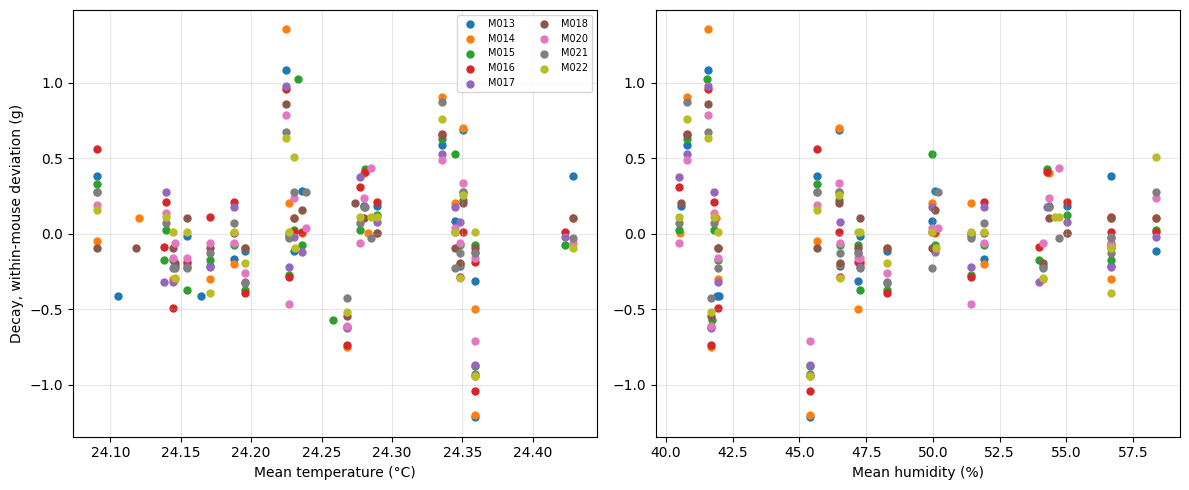

In [38]:
transitions['decay_centered'] = transitions.groupby('subject_id')['decay'].transform(lambda x: x - x.mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10.colors
mice = sorted(transitions['subject_id'].unique())

for i, subject_id in enumerate(mice):
    s = transitions[transitions['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    axes[0].scatter(s['mean_temp'], s['decay_centered'], color=color, label=subject_id, s=25)
    axes[1].scatter(s['mean_humidity'], s['decay_centered'], color=color, s=25)

axes[0].set_xlabel('Mean temperature (°C)')
axes[0].set_ylabel('Decay, within-mouse deviation (g)')
axes[1].set_xlabel('Mean humidity (%)')
axes[0].legend(fontsize=7, ncol=2)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

y_ij = β₀ + β₁·mean_temp_ij + β₂·mean_humidity_ij + β₃·pct_baseline_ij + b_i + ε_ij

Here y_ij is decay_per_day for that transition.
β₀, β₁, β₂, β₃ are the fixed effects — the "Intercept", mean_temp, mean_humidity, and pct_baseline_t rows in the summary output. These are population-level coefficients: one shared value for all mice, telling you how decay rate changes on average per unit of temperature, humidity, or baseline percentage, holding the others fixed.

In [39]:
import statsmodels.formula.api as smf

model = smf.mixedlm("decay ~ mean_temp + mean_humidity + weight_ratio_t + water_given_t",
                     data=transitions, groups=transitions["subject_id"])
result = model.fit()
print(result.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  decay   
No. Observations:  207      Method:              REML    
No. Groups:        9        Scale:               0.0749  
Min. group size:   23       Log-Likelihood:      -39.7155
Max. group size:   23       Converged:           Yes     
Mean group size:   23.0                                  
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.861    5.264  0.164 0.870 -9.456 11.178
mean_temp      -0.085    0.224 -0.381 0.703 -0.525  0.354
mean_humidity  -0.018    0.004 -4.930 0.000 -0.025 -0.011
weight_ratio_t  3.117    1.037  3.007 0.003  1.085  5.149
water_given_t   0.634    0.045 14.211 0.000  0.546  0.721
Group Var       0.015    0.041                           



In [40]:
def compute_metrics(cv_results):
    actual = cv_results['actual']
    predicted = cv_results['predicted']
    error = actual - predicted

    mae = error.abs().mean()
    rmse = np.sqrt((error ** 2).mean())
    corr = actual.corr(predicted)  # Pearson r: do predicted values move with actual ones?
    ss_res = (error ** 2).sum()
    ss_tot = ((actual - actual.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot  # fraction of variance in 'actual' explained by 'predicted'

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'corr': corr}

In [41]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def cross_validate_leave_one_mouse_out(transitions, formula, target_col='decay'):
    predictions = []
    for held_out in transitions['subject_id'].unique():
        train = transitions[transitions['subject_id'] != held_out]
        test = transitions[transitions['subject_id'] == held_out]
        if test.empty or train['subject_id'].nunique() < 2:
            continue
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            m = smf.mixedlm(formula, data=train, groups=train["subject_id"]).fit()
        if any("failed to converge" in str(w.message) for w in caught):
            print(f"Optimization failed for held-out mouse {held_out} (formula: {formula})")
        for w in caught:
            print(f"[held out: {held_out}] {w.category.__name__}: {w.message}")
        pred = m.predict(test)
        predictions.append(pd.DataFrame({'subject_id': held_out, 'actual': test[target_col], 'predicted': pred}))

    cv_results = pd.concat(predictions)
    errors = compute_metrics(cv_results)
    return cv_results, errors

In [42]:
transitions = transitions.sort_values(['subject_id', 't_start']).reset_index(drop=True)

# --- naive baseline 1: expanding (causal) mean of past decay values per mouse ---
transitions['naive_expanding_pred'] = (
    transitions.groupby('subject_id')['decay']
               .transform(lambda x: x.shift(1).expanding().mean())
)
valid_expanding = transitions['naive_expanding_pred'].notna()
cv_results_naive_expanding = (
    transitions.loc[valid_expanding, ['subject_id', 'decay', 'naive_expanding_pred']]
    .rename(columns={'decay': 'actual', 'naive_expanding_pred': 'predicted'})
)
errors_naive_expanding = compute_metrics(cv_results_naive_expanding)

# --- naive baseline 2: mouse's own overall mean decay ---
transitions['naive_mean_pred'] = transitions.groupby('subject_id')['decay'].transform('mean')
cv_results_naive_mean = (
    transitions[['subject_id', 'decay', 'naive_mean_pred']]
    .rename(columns={'decay': 'actual', 'naive_mean_pred': 'predicted'})
)
errors_naive_mean = compute_metrics(cv_results_naive_mean)

[held out: M016] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M018] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M016] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M018] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
Optimization failed for held-out mouse M016 (formula: decay ~ mean_temp + weight_ratio_t + water_given_t + elapsed_days + C(sex))
[held out: M016] ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
[held out: M016] ConvergenceWarning: Retrying MixedLM optimization with lbfgs
[held out: M016] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
Optimization failed for held-out mouse M0

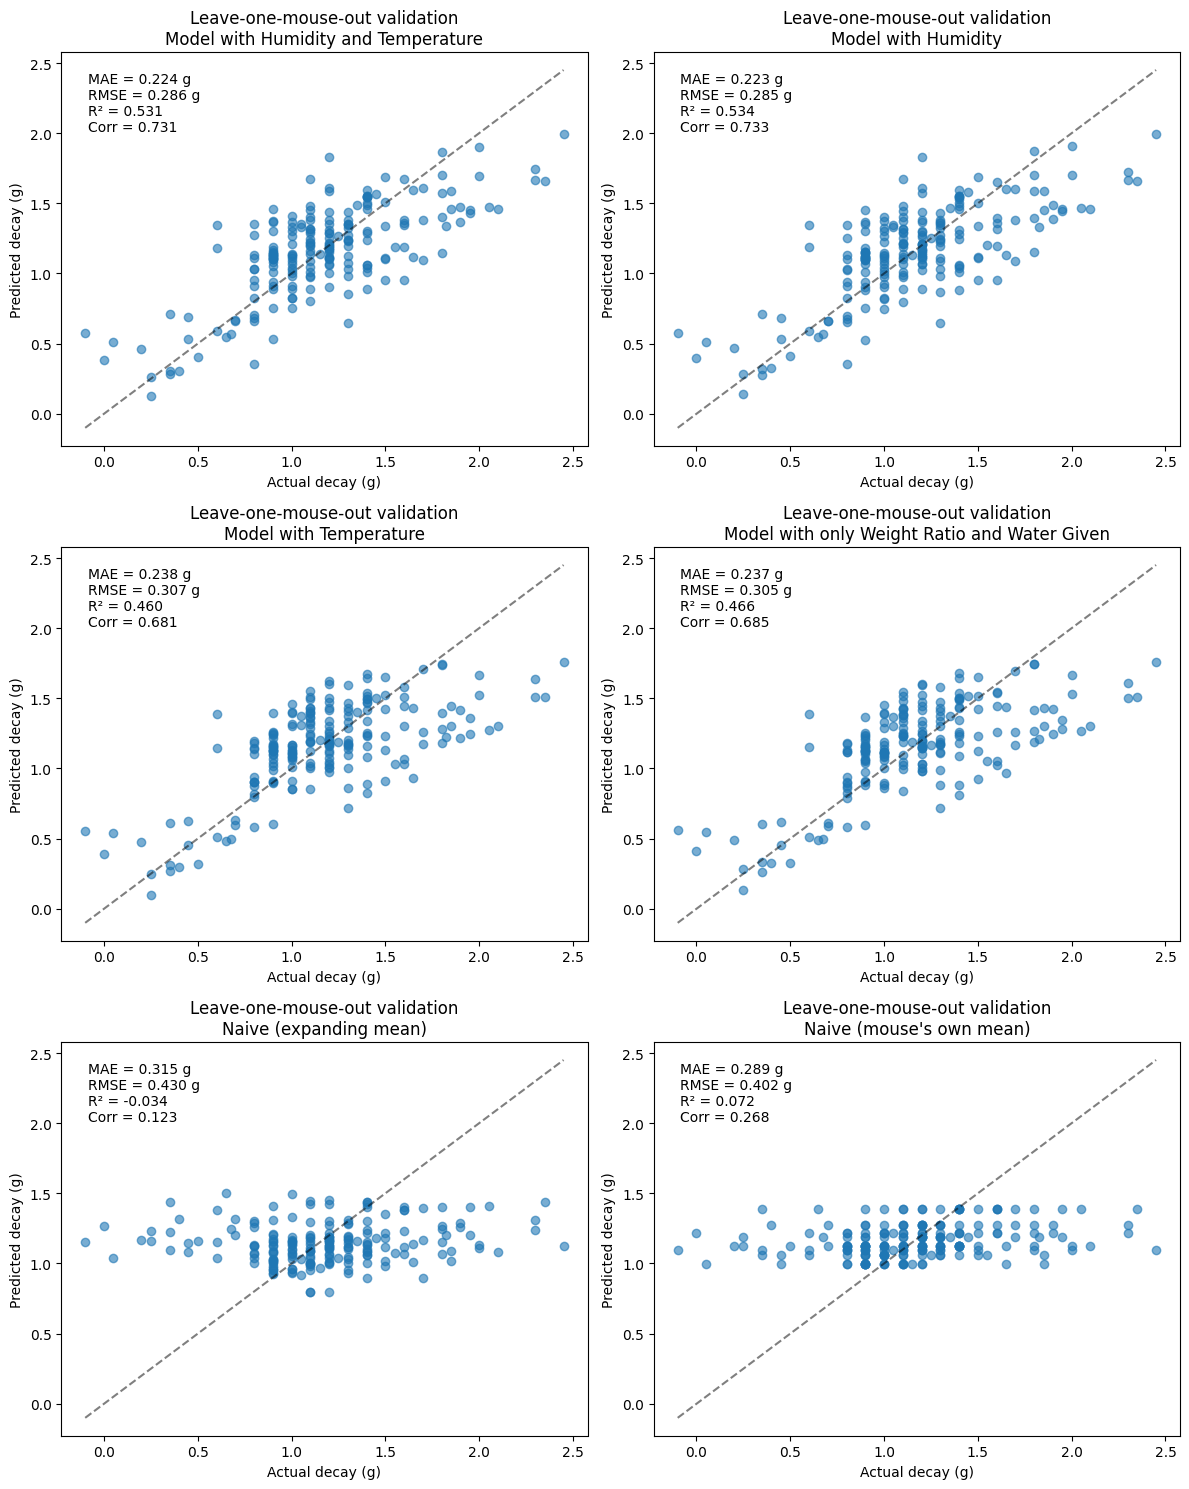

In [43]:
cv_results_ht, errors_ht = cross_validate_leave_one_mouse_out(transitions, "decay ~ mean_temp + mean_humidity + weight_ratio_t + water_given_t + elapsed_days + C(sex)")
cv_results_h, errors_h = cross_validate_leave_one_mouse_out(transitions, "decay ~ mean_humidity + weight_ratio_t + water_given_t + elapsed_days + C(sex)")
cv_results_t, errors_t = cross_validate_leave_one_mouse_out(transitions, "decay ~ mean_temp + weight_ratio_t + water_given_t + elapsed_days + C(sex)")
cv_results, errors = cross_validate_leave_one_mouse_out(transitions, "decay ~ weight_ratio_t + water_given_t + elapsed_days + C(sex)")

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

axes[0, 0].scatter(cv_results_ht['actual'], cv_results_ht['predicted'], alpha=0.6)
lims = [cv_results_ht[['actual', 'predicted']].min().min(), cv_results_ht[['actual', 'predicted']].max().max()]
axes[0, 0].plot(lims, lims, 'k--', alpha=0.5)
axes[0, 0].set_xlabel('Actual decay (g)')
axes[0, 0].set_ylabel('Predicted decay (g)')
axes[0, 0].set_title('Leave-one-mouse-out validation\nModel with Humidity and Temperature')
axes[0, 0].text(0.05, 0.95, f'MAE = {errors_ht["mae"]:.3f} g\nRMSE = {errors_ht["rmse"]:.3f} g\nR² = {errors_ht["r2"]:.3f}\nCorr = {errors_ht["corr"]:.3f}', transform=axes[0, 0].transAxes,
                ha='left', va='top')

axes[0, 1].scatter(cv_results_h['actual'], cv_results_h['predicted'], alpha=0.6)
lims = [cv_results_h[['actual', 'predicted']].min().min(), cv_results_h[['actual', 'predicted']].max().max()]
axes[0, 1].plot(lims, lims, 'k--', alpha=0.5)
axes[0, 1].set_xlabel('Actual decay (g)')
axes[0, 1].set_ylabel('Predicted decay (g)')
axes[0, 1].set_title('Leave-one-mouse-out validation\nModel with Humidity')
axes[0, 1].text(0.05, 0.95, f'MAE = {errors_h["mae"]:.3f} g\nRMSE = {errors_h["rmse"]:.3f} g\nR² = {errors_h["r2"]:.3f}\nCorr = {errors_h["corr"]:.3f}', transform=axes[0, 1].transAxes,
                ha='left', va='top')

axes[1, 0].scatter(cv_results_t['actual'], cv_results_t['predicted'], alpha=0.6)
lims = [cv_results_t[['actual', 'predicted']].min().min(), cv_results_t[['actual', 'predicted']].max().max()]
axes[1, 0].plot(lims, lims, 'k--', alpha=0.5)
axes[1, 0].set_xlabel('Actual decay (g)')
axes[1, 0].set_ylabel('Predicted decay (g)')
axes[1, 0].set_title('Leave-one-mouse-out validation\nModel with Temperature')
axes[1, 0].text(0.05, 0.95, f'MAE = {errors_t["mae"]:.3f} g\nRMSE = {errors_t["rmse"]:.3f} g\nR² = {errors_t["r2"]:.3f}\nCorr = {errors_t["corr"]:.3f}', transform=axes[1, 0].transAxes,
                ha='left', va='top')

axes[1, 1].scatter(cv_results['actual'], cv_results['predicted'], alpha=0.6)
lims = [cv_results[['actual', 'predicted']].min().min(), cv_results[['actual', 'predicted']].max().max()]
axes[1, 1].plot(lims, lims, 'k--', alpha=0.5)
axes[1, 1].set_xlabel('Actual decay (g)')
axes[1, 1].set_ylabel('Predicted decay (g)')
axes[1, 1].set_title('Leave-one-mouse-out validation\nModel with only Weight Ratio and Water Given')
axes[1, 1].text(0.05, 0.95, f'MAE = {errors["mae"]:.3f} g\nRMSE = {errors["rmse"]:.3f} g\nR² = {errors["r2"]:.3f}\nCorr = {errors["corr"]:.3f}', transform=axes[1, 1].transAxes,
                ha='left', va='top')

axes[2, 0].scatter(cv_results_naive_expanding['actual'], cv_results_naive_expanding['predicted'], alpha=0.6)
lims = [cv_results_naive_expanding[['actual', 'predicted']].min().min(), cv_results_naive_expanding[['actual', 'predicted']].max().max()]
axes[2, 0].plot(lims, lims, 'k--', alpha=0.5)
axes[2, 0].set_xlabel('Actual decay (g)')
axes[2, 0].set_ylabel('Predicted decay (g)')
axes[2, 0].set_title('Leave-one-mouse-out validation\nNaive (expanding mean)')
axes[2, 0].text(0.05, 0.95, f'MAE = {errors_naive_expanding["mae"]:.3f} g\nRMSE = {errors_naive_expanding["rmse"]:.3f} g\nR² = {errors_naive_expanding["r2"]:.3f}\nCorr = {errors_naive_expanding["corr"]:.3f}', transform=axes[2, 0].transAxes,
                ha='left', va='top')

axes[2, 1].scatter(cv_results_naive_mean['actual'], cv_results_naive_mean['predicted'], alpha=0.6)
lims = [cv_results_naive_mean[['actual', 'predicted']].min().min(), cv_results_naive_mean[['actual', 'predicted']].max().max()]
axes[2, 1].plot(lims, lims, 'k--', alpha=0.5)
axes[2, 1].set_xlabel('Actual decay (g)')
axes[2, 1].set_ylabel('Predicted decay (g)')
axes[2, 1].set_title('Leave-one-mouse-out validation\nNaive (mouse\'s own mean)')
axes[2, 1].text(0.05, 0.95, f'MAE = {errors_naive_mean["mae"]:.3f} g\nRMSE = {errors_naive_mean["rmse"]:.3f} g\nR² = {errors_naive_mean["r2"]:.3f}\nCorr = {errors_naive_mean["corr"]:.3f}', transform=axes[2, 1].transAxes,
                ha='left', va='top')

plt.tight_layout()
plt.show()

Just a check if the target variable is the net change

[held out: M016] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M018] ConvergenceWarning: The MLE may be on the boundary of the parameter space.


Text(0.05, 0.95, 'MAE = 0.223 g\nRMSE = 0.285 g\nR² = 0.334\nCorr = 0.589')

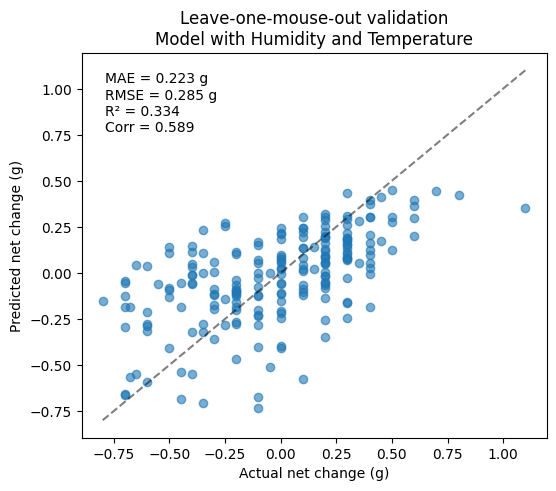

In [44]:
cv_results_net, errors_net = cross_validate_leave_one_mouse_out(transitions, "net_change ~ standardize(mean_humidity) + standardize(weight_ratio_t) + standardize(elapsed_days) + standardize(water_given_t)", target_col='net_change')

fig, axes = plt.subplots(1, 1, figsize=(6, 5))

axes.scatter(cv_results_net['actual'], cv_results_net['predicted'], alpha=0.6)
lims = [cv_results_net[['actual', 'predicted']].min().min(), cv_results_net[['actual', 'predicted']].max().max()]
axes.plot(lims, lims, 'k--', alpha=0.5)
axes.set_xlabel('Actual net change (g)')
axes.set_ylabel('Predicted net change (g)')
axes.set_title('Leave-one-mouse-out validation\nModel with Humidity and Temperature')
axes.text(0.05, 0.95, f'MAE = {errors_net["mae"]:.3f} g\nRMSE = {errors_net["rmse"]:.3f} g\nR² = {errors_net["r2"]:.3f}\nCorr = {errors_net["corr"]:.3f}', transform=axes.transAxes,
                ha='left', va='top')


In [45]:
def recommend_water_search(current_weight, wr_start_weight, target_pct, days_until_next,
                            mean_humidity_forecast, sex, model_result,
                            subject_id=None, lo=0.0, hi=3.0, tol=1e-3):
    target_weight_g = wr_start_weight * target_pct / 100

    # this mouse's own fitted random intercept, if it was in the training data
    b_i = 0.0
    if subject_id is not None and subject_id in model_result.random_effects:
        b_i = model_result.random_effects[subject_id]['Group']

    def predicted_weight_next(water_given):
        pred_decay = model_result.predict(pd.DataFrame({
            'mean_humidity': [mean_humidity_forecast],
            'weight_ratio_t': [current_weight / wr_start_weight],
            'water_given_t': [water_given],
            'elapsed_days': [days_until_next],
            'sex': [sex]
        })).iloc[0] + b_i
        return (current_weight + water_given) - pred_decay

    while hi - lo > tol:
        mid = (lo + hi) / 2
        if predicted_weight_next(mid) < target_weight_g:
            lo = mid   # predicted weight too low -> try more water
        else:
            hi = mid   # predicted weight too high -> try less water
    return (lo + hi) / 2

In [46]:
def recommend_water_simple(transitions, current_weight, wr_start_weight, target_pct, days_until_next, subject_id):
    mouse_avg_decay = transitions.groupby('subject_id')['decay'].mean()
    decay_rate = mouse_avg_decay.get(subject_id, transitions['decay'].mean())
    target_weight_g = wr_start_weight * target_pct / 100
    required_weight_after_watering = target_weight_g + decay_rate * days_until_next
    return max(required_weight_after_watering - current_weight, 0)